In [ ]:
from datasets import load_dataset

dataset = load_dataset("google/speech_commands", "v0.01")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 51093
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 6799
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 3081
    })
})
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}
Label names: ['yes', 'no

In [58]:
print(dataset.keys())
print(dataset["validation"].features)
print(dataset["validation"][0])
print(f"Label names: {dataset['train'].features['label'].names}")

dict_keys(['train', 'validation', 'test'])
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}
{'file': 'eight/2ce7534c_nohash_1.wav', 'audio': {'path': 'eight/2ce7534c_nohash_1.wav', 'array': array([-0.00076294, -0.00201416, -0.00204468, ..., -0.00439453,
       -0.00189209, -0.00115967], shape=(16000,)), 'sampling_rate': 16000}, 'label': 18, 'is_unknown': True, 'speaker_id': '2ce7534c', 'utterance_id': 1}
Label names: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'th

In [67]:
label_names = dataset["train"].features["label"].names

DIGIT_LABELS = ['zero','one','two','three','four','five','six','seven','eight','nine']
digit_to_idx = {label_names.index(d): i for i, d in enumerate(DIGIT_LABELS)}
idx_to_digit = {i: d for i, d in enumerate(DIGIT_LABELS)}

print("Label mapping:")
for original_id, new_id in digit_to_idx.items():
    print(f"  original label {original_id} ({label_names[original_id]}) -> model label {new_id}")

Label mapping:
  original label 10 (zero) -> model label 0
  original label 11 (one) -> model label 1
  original label 12 (two) -> model label 2
  original label 13 (three) -> model label 3
  original label 14 (four) -> model label 4
  original label 15 (five) -> model label 5
  original label 16 (six) -> model label 6
  original label 17 (seven) -> model label 7
  original label 18 (eight) -> model label 8
  original label 19 (nine) -> model label 9


In [70]:

digit_ids = set(digit_to_idx.keys())

def is_digit(example):
    return example["label"] in digit_ids

dataset_digits = dataset.filter(is_digit)
print(dataset_digits)


Filter:   0%|          | 0/18620 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2494 [00:00<?, ? examples/s]

Filter:   0%|          | 0/160 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 18620
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 2494
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 160
    })
})


Checking class inbalances after filtering

In [85]:
print("digit_ids:", digit_ids)

import collections
test_label_counts = collections.Counter(dataset["test"]["label"])
print("\nAll labels in test set:")
for label_id, count in sorted(test_label_counts.items()):
    print(f"  {label_id} ({label_names[label_id]}): {count}")

digit_ids: {10, 11, 12, 13, 14, 15, 16, 17, 18, 19}

All labels in test set:
  10 (zero): 13
  11 (one): 16
  12 (two): 16
  13 (three): 15
  14 (four): 9
  15 (five): 23
  16 (six): 11
  17 (seven): 16
  18 (eight): 16
  19 (nine): 25


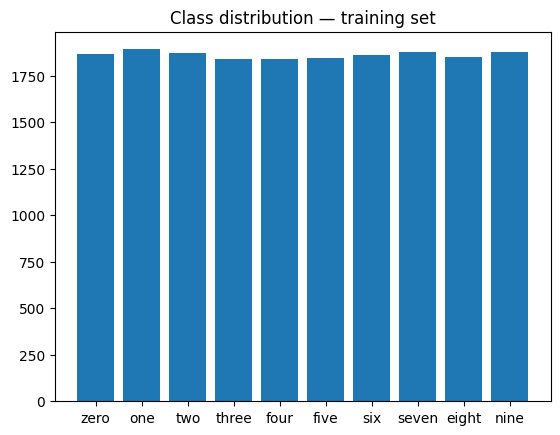

In [84]:
import collections, matplotlib.pyplot as plt
counts = collections.Counter(dataset_digits["train"]["label"])
plt.bar([label_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)])
plt.title("Class distribution — training set")
plt.savefig("class_balance.png")

{'file': 'eight/8f4c551f_nohash_3.wav', 'audio': {'path': 'eight/8f4c551f_nohash_3.wav', 'array': array([ 0.00015259,  0.00030518,  0.00030518, ..., -0.00027466,
       -0.00027466, -0.00036621], shape=(16000,)), 'sampling_rate': 16000}, 'label': 18, 'is_unknown': True, 'speaker_id': '8f4c551f', 'utterance_id': 3}
Audio shape: (16000,), Label: eight (eight)


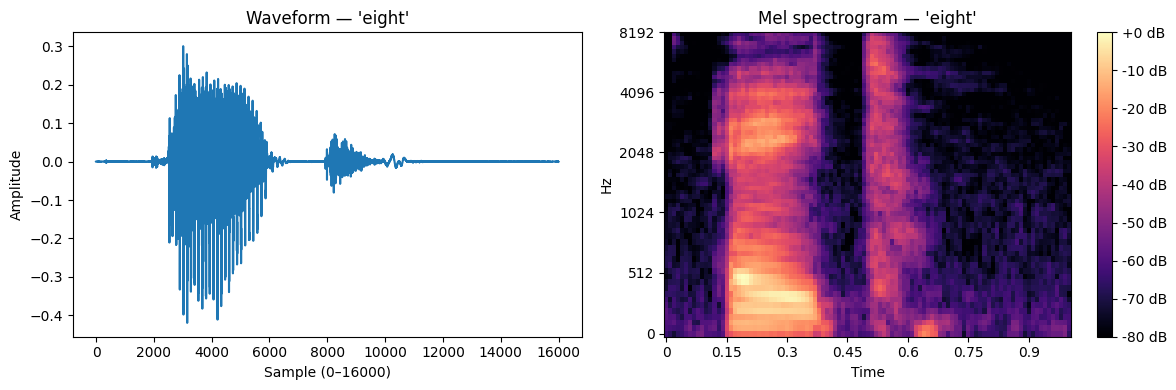

In [77]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def compute_mel(audio_array, sr=16000, for_model=False):
    # Pad or truncate if needed
    target_length = 16000
    if len(audio_array) < target_length:
        audio_array = np.pad(audio_array, (0, target_length - len(audio_array)))
    else:
        audio_array = audio_array[:target_length]

    # Core computation — same either way
    mel = librosa.feature.melspectrogram(
        y=audio_array, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if for_model:
        # Normalize and add channel dimension for CNN
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return mel_norm[..., np.newaxis]  # (64, 101, 1)
    else:
        # Return raw dB values for visualization
        return mel_db  # (64, 101)

sample = dataset_digits["train"][0]
print(sample)
audio = np.array(sample["audio"]["array"], dtype=np.float32)
label = dataset_digits["train"].features["label"].names[sample["label"]]
word = label_names[sample["label"]]
print(f"Audio shape: {audio.shape}, Label: {label} ({word})")
mel = compute_mel(audio)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — raw waveform
axes[0].plot(audio)
axes[0].set_title(f"Waveform — '{word}'")
axes[0].set_xlabel("Sample (0–16000)")
axes[0].set_ylabel("Amplitude")

# Right — mel spectrogram
mel = compute_mel(audio)
img = librosa.display.specshow(
    mel, sr=16000, hop_length=160,
    x_axis='time', y_axis='mel',
    ax=axes[1]
)
axes[1].set_title(f"Mel spectrogram — '{word}'")
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig("waveform_vs_spectrogram.png")
plt.show()

Preprocessing functions for both mel spectrograms and MFCC for comparison

In [78]:
def audio_to_mel(example):
    audio = np.array(example["audio"]["array"], dtype=np.float32)
    sr = example["audio"]["sampling_rate"]
    
    # Pad or truncate to exactly 1 second
    target_length = 16000
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    
    # Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    
    # Convert to decibels
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Normalize to [0, 1]
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    
    # Add channel dimension (64, 101) → (64, 101, 1)
    return mel_norm[..., np.newaxis]


def audio_to_mfcc(example):
    audio = np.array(example["audio"]["array"], dtype=np.float32)
    sr = example["audio"]["sampling_rate"]
    
    # Pad or truncate to exactly 1 second
    target_length = 16000
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    
    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=40, n_fft=400, hop_length=160
    )
    
    # Normalize each coefficient independently
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
    
    # Add channel dimension (40, 101) → (40, 101, 1)
    return mfcc[..., np.newaxis]

Word: 'eight'
Mel spectrogram shape:  (64, 101, 1)
MFCC shape:             (40, 101, 1)
Mel value range:  min=0.000  max=1.000
MFCC value range: min=-3.904  max=3.853


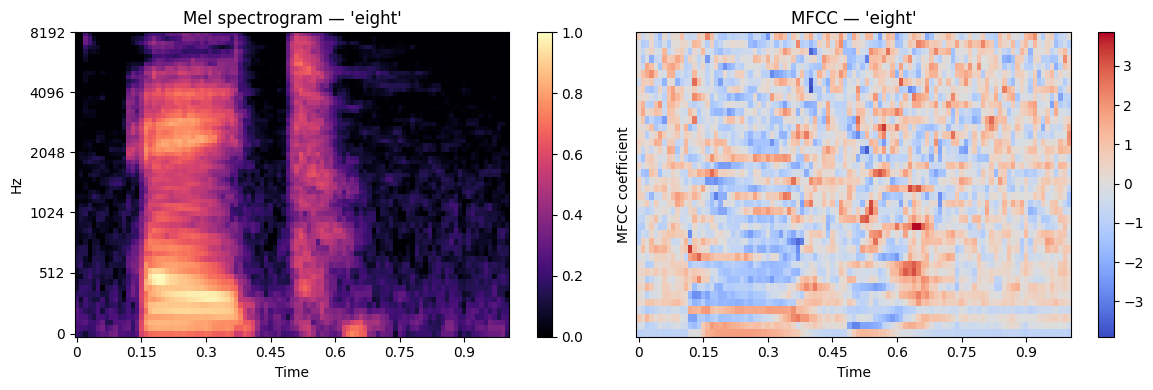

In [79]:
sample = dataset_digits["train"][0]
word = label_names[sample["label"]]

# Test both functions
mel_output = audio_to_mel(sample)
mfcc_output = audio_to_mfcc(sample)

print(f"Word: '{word}'")
print(f"Mel spectrogram shape:  {mel_output.shape}")   # should be (64, 101, 1)
print(f"MFCC shape:             {mfcc_output.shape}")  # should be (40, 101, 1)
print(f"Mel value range:  min={mel_output.min():.3f}  max={mel_output.max():.3f}")   # should be 0.0 to 1.0
print(f"MFCC value range: min={mfcc_output.min():.3f}  max={mfcc_output.max():.3f}")

# Visualize both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

img1 = librosa.display.specshow(
    mel_output[:, :, 0],
    sr=16000, hop_length=160,
    x_axis='time', y_axis='mel',
    ax=axes[0]
)
axes[0].set_title(f"Mel spectrogram — '{word}'")
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(
    mfcc_output[:, :, 0],
    sr=16000, hop_length=160,
    x_axis='time',
    ax=axes[1]
)
axes[1].set_title(f"MFCC — '{word}'")
axes[1].set_ylabel("MFCC coefficient")
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.savefig("mel_vs_mfcc.png")
plt.show()